In [40]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score

available_fonts = {font.name for font in fm.fontManager.ttflist}
for korean_font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if korean_font in available_fonts:
        plt.rcParams['font.family'] = korean_font
        break
plt.rcParams['axes.unicode_minus'] = False


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        has_repo_markers = (candidate / '.git').exists() or (candidate / 'notebooks').exists()
        has_data_dir = (candidate / 'data').exists()
        if has_repo_markers and has_data_dir:
            return candidate
    raise FileNotFoundError(
        'Project root not found. Run this notebook from the repository root, '
        'or set PROJECT_ROOT to the repository path.'
    )


project_root_env = os.environ.get('PROJECT_ROOT')
PROJECT_ROOT = Path(project_root_env).expanduser().resolve() if project_root_env else find_project_root(Path.cwd())

DATA_DIR = PROJECT_ROOT / 'data' / 'labeled'
required_data_files = ['train_labeled.csv', 'val_labeled.csv', 'test_labeled.csv']

missing_data_files = [str(DATA_DIR / name) for name in required_data_files if not (DATA_DIR / name).exists()]
if missing_data_files:
    raise FileNotFoundError('Missing split files: ' + ', '.join(missing_data_files))

OUTPUT_DIR = PROJECT_ROOT / 'models' / 'MLP'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('MLP result output dir:', OUTPUT_DIR)

# 데이터 로드
train_df = pd.read_csv(DATA_DIR / 'train_labeled.csv')
val_df = pd.read_csv(DATA_DIR / 'val_labeled.csv')
test_df = pd.read_csv(DATA_DIR / 'test_labeled.csv')
train_df.head()

# 1,2,3 -> 0,1,2 변환
train_df['digital_stage'] = train_df['digital_stage'] - 1
val_df['digital_stage'] = val_df['digital_stage'] - 1
test_df['digital_stage'] = test_df['digital_stage'] - 1

Project root: C:\Users\user\Documents\GitHub\Team-3
MLP result output dir: C:\Users\user\Documents\GitHub\Team-3\models\MLP


In [9]:
# 모델 공통 feature와 평가지표를 model_config.py에서 불러온다
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from models.model_config import MODEL_FEATURES, TARGET_COL, EVAL_METRICS

print('모델에 사용할 feature 수:', len(MODEL_FEATURES))
print('모델의 타겟 컬럼:', TARGET_COL)
print('모델 평가 지표:', EVAL_METRICS)

모델에 사용할 feature 수: 118
모델의 타겟 컬럼: digital_stage
모델 평가 지표: ('accuracy', 'macro_f1', 'weighted_f1')


In [41]:
# pytorch 설치 확인
try:
    import torch
    print('PyTorch가 이미 설치되어 있습니다.')
except ImportError:
    raise ImportError(
        'PyTorch가 설치되어 있지 않습니다. MLP 모델 실행 전 설치가 필요합니다.'
    )

# CUDA 사용 가능 시 GPU, 아니면 CPU 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('사용 디바이스:', device)

PyTorch가 이미 설치되어 있습니다.
사용 디바이스: cpu


In [12]:
features = MODEL_FEATURES
# ===================== 데이터 텐서 변환 =====================
def df_to_tensor(df, feature_cols, label_col):
    # DataFrame의 feature 컬럼을 float32 텐서로 변환 (MLP 입력용)
    X = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    # 레이블 컬럼을 long 텐서로 변환 (CrossEntropyLoss 요구 타입)
    y = torch.tensor(df[label_col].values, dtype=torch.long)
    return X, y

train_X, train_y = df_to_tensor(train_df, features, 'digital_stage')
val_X,   val_y   = df_to_tensor(val_df,   features, 'digital_stage')
test_X,  test_y  = df_to_tensor(test_df,  features, 'digital_stage')


# ===================== 데이터로더 생성 =====================
train_dataset = TensorDataset(train_X, train_y)
val_dataset   = TensorDataset(val_X,   val_y)
test_dataset  = TensorDataset(test_X,  test_y)

# shuffle=True: 매 에폭마다 배치 순서를 섞어 과적합 방지
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# 검증/테스트는 순서 상관없으므로 shuffle 불필요
val_loader   = DataLoader(val_dataset,  batch_size=64)
test_loader  = DataLoader(test_dataset, batch_size=64)


# ===================== 모델 정의 =====================
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            # 은닉층 1: 입력 → 256
            # BatchNorm: 학습 안정화 / ReLU: 비선형 활성화 / Dropout: 과적합 방지
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),

            # 은닉층 2: 256 → 128
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),

            # 은닉층 3: 128 → 64
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),

            # 출력층: 64 → 클래스 수 (Softmax 없음 - CrossEntropyLoss에 내장)
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.layers(x)

In [13]:
# ===================== 검증 함수 =====================
def validate_model(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            _, predicted = torch.max(model(X_batch), 1)
            preds.extend(predicted.cpu().numpy())
            labels.extend(y_batch.cpu().numpy())
    f1 = f1_score(labels, preds, average='weighted')
    return f1, preds, labels


# ===================== 학습 함수 =====================
def train_model(model, train_loader, val_loader,
                criterion, optimizer, scheduler,  # 인자로 받음
                num_epochs=50, save_path=None):
    best_val_f1 = 0.0
    val_f1s, train_losses = [], []

    for epoch in range(num_epochs):
        # 학습
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

        # 검증
        val_f1, val_preds, val_labels = validate_model(model, val_loader)
        scheduler.step(val_f1)
        val_f1s.append(val_f1)
        print(f'Epoch {epoch+1}/{num_epochs} | Loss: {train_losses[-1]:.4f} | Val F1: {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            if save_path:
                torch.save(model.state_dict(), save_path)

    return val_f1s, val_preds, val_labels, train_losses


# ===================== 실행 =====================
input_dim   = len(features)
num_classes = 3

model= MLP(input_dim, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5)

val_f1s, val_preds, val_labels, train_losses = train_model(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    num_epochs=50,
    save_path=OUTPUT_DIR / 'best_mlp_model.pth'
)

Epoch 1/50 | Loss: 0.2392 | Val F1: 0.9767
Epoch 2/50 | Loss: 0.1620 | Val F1: 0.9598
Epoch 3/50 | Loss: 0.1498 | Val F1: 0.9712
Epoch 4/50 | Loss: 0.1429 | Val F1: 0.9716
Epoch 5/50 | Loss: 0.1341 | Val F1: 0.9535
Epoch 6/50 | Loss: 0.1271 | Val F1: 0.9719
Epoch 7/50 | Loss: 0.1288 | Val F1: 0.9791
Epoch 8/50 | Loss: 0.1201 | Val F1: 0.9726
Epoch 9/50 | Loss: 0.1228 | Val F1: 0.9721
Epoch 10/50 | Loss: 0.1180 | Val F1: 0.9718
Epoch 11/50 | Loss: 0.1217 | Val F1: 0.9749
Epoch 12/50 | Loss: 0.1183 | Val F1: 0.9736
Epoch 13/50 | Loss: 0.1159 | Val F1: 0.9691
Epoch 14/50 | Loss: 0.1088 | Val F1: 0.9745
Epoch 15/50 | Loss: 0.0996 | Val F1: 0.9696
Epoch 16/50 | Loss: 0.0928 | Val F1: 0.9786
Epoch 17/50 | Loss: 0.0906 | Val F1: 0.9631
Epoch 18/50 | Loss: 0.0846 | Val F1: 0.9696
Epoch 19/50 | Loss: 0.0957 | Val F1: 0.9781
Epoch 20/50 | Loss: 0.0850 | Val F1: 0.9781
Epoch 21/50 | Loss: 0.0880 | Val F1: 0.9767
Epoch 22/50 | Loss: 0.0839 | Val F1: 0.9776
Epoch 23/50 | Loss: 0.0788 | Val F1: 0.97

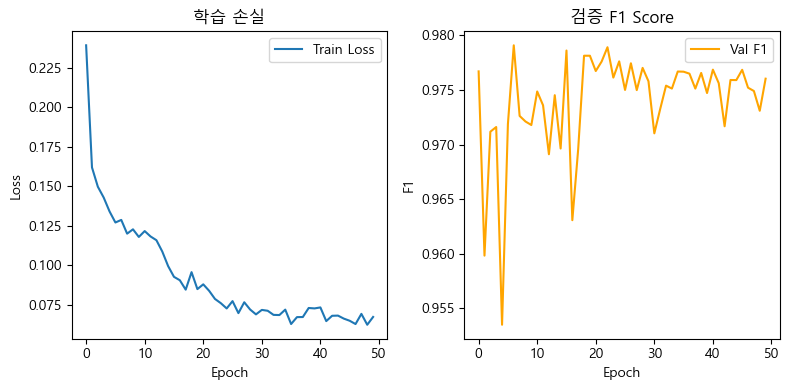

In [14]:

# 학습 완료 후 그래프
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.plot(train_losses, label='Train Loss')
ax1.set_title('학습 손실')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(val_f1s, label='Val F1', color='orange')
ax2.set_title('검증 F1 Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1')
ax2.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curve.png')
plt.show()

출력 해석

- 학습 손실(왼쪽): 초반 급감 후 완만히 감소함. 대략 0.24 → 0.06대까지 내려가서 최적화는 정상적으로 진행됨.
- 검증 F1(오른쪽): 초반 변동폭이 크지만, 이후 0.97~0.98 구간에서 안정적으로 유지됨.
- 과적합 징후: 뚜렷하지 않음. 보통 과적합이면 검증 F1이 내려가는데, 여기선 후반까지 크게 무너지지 않음.
- 수렴 시점: 대략 20~30 epoch 이후에는 성능 개선 폭이 작음. 학습을 더 길게 해도 이득이 크지 않은 형태임.

결론:
- 현재 학습은 정상 수렴 + 일반화도 양호한 편임.
- 실전 기준으로는 25~35 epoch 부근에서 early stopping 걸어도 거의 같은 성능 기대 가능함.
- 초반 F1 출렁임 줄이려면 lr warmup, seed 고정, 배치 크기/스케줄러 미세조정이 유효함.

In [16]:
#val 평가와 test 평가 비교
from models.model_config import evaluate
# 최적 모델 로드
model.load_state_dict(torch.load(OUTPUT_DIR / 'best_mlp_model.pth'))
model.eval()
test_preds, test_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        _, predicted = torch.max(model(X_batch), 1)
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(y_batch.cpu().numpy())

evaluate(val_labels, val_preds,test_labels, test_preds, model_name="MLP")




MLP evaluation 결과가 models\MLP\MLP_evaluation.txt에 저장되었습니다.
  MLP validation 평가 결과
Accuracy   : 0.9761
F1 macro   : 0.9756
F1 weighted: 0.9760
              precision    recall  f1-score   support

           0     0.9836    0.9922    0.9878      2294
           1     0.9741    0.9604    0.9672      2273
           2     0.9685    0.9753    0.9719      1700

    accuracy                         0.9761      6267
   macro avg     0.9754    0.9760    0.9756      6267
weighted avg     0.9760    0.9761    0.9760      6267

  MLP test 평가 결과
Accuracy   : 0.9748
F1 macro   : 0.9752
F1 weighted: 0.9748
              precision    recall  f1-score   support

           0     0.9703    0.9920    0.9810      2238
           1     0.9711    0.9611    0.9661      2341
           2     0.9862    0.9710    0.9785      1688

    accuracy                         0.9748      6267
   macro avg     0.9758    0.9747    0.9752      6267
weighted avg     0.9749    0.9748    0.9748      6267



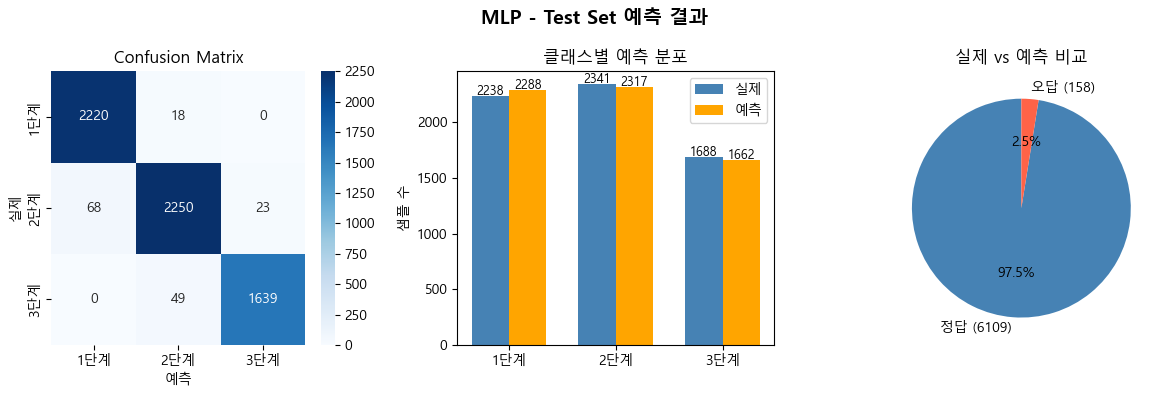

In [17]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics import confusion_matrix


fig, axes = plt.subplots(1, 3, figsize=(12, 4))
class_names = ['1단계', '2단계', '3단계']

# ===================== 1. Confusion Matrix =====================
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('실제')
axes[0].set_xlabel('예측')

# ===================== 2. 클래스별 예측 분포 (막대그래프) =====================
import numpy as np

actual_counts = [test_labels.count(i) for i in range(3)]
pred_counts   = [test_preds.count(i)  for i in range(3)]

x = np.arange(3)
width = 0.35
axes[1].bar(x - width/2, actual_counts, width, label='실제',    color='steelblue')
axes[1].bar(x + width/2, pred_counts,   width, label='예측',    color='orange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names)
axes[1].set_title('클래스별 예측 분포')
axes[1].set_ylabel('샘플 수')
axes[1].legend()

# 수치 표시
for i, (a, p) in enumerate(zip(actual_counts, pred_counts)):
    axes[1].text(i - width/2, a + 10, str(a), ha='center', fontsize=9)
    axes[1].text(i + width/2, p + 10, str(p), ha='center', fontsize=9)

# ===================== 3. 실제 vs 예측 비교 (정답/오답) =====================
correct   = [1 if t == p else 0 for t, p in zip(test_labels, test_preds)]
correct_count   = sum(correct)
incorrect_count = len(correct) - correct_count

axes[2].pie(
    [correct_count, incorrect_count],
    labels=[f'정답 ({correct_count})', f'오답 ({incorrect_count})'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90
)
axes[2].set_title('실제 vs 예측 비교')

plt.suptitle('MLP - Test Set 예측 결과', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'MLP_prediction_results.png', dpi=300)
plt.show()

## 결과 정리

### 1) 최종 성능 요약
- Validation
  - Accuracy: 0.9711
  - F1 macro: 0.9706
  - F1 weighted: 0.9711
- Test
  - Accuracy: 0.9727
  - F1 macro: 0.9732
  - F1 weighted: 0.9726

### 2) 클래스별 Test 성능
| 클래스 | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| 1단계 (0) | 0.9739 | 0.9839 | 0.9789 | 2238 |
| 2단계 (1) | 0.9771 | 0.9492 | 0.9629 | 2341 |
| 3단계 (2) | 0.9654 | 0.9905 | 0.9778 | 1688 |

### 3) 시각화 결과 분석

#### 3-1. Confusion Matrix
- 대각선 값이 전반적으로 높아 전체 분류 성능이 안정적.
- 2단계에서 다른 단계로 일부 이동하는 패턴이 상대적으로 더 뚜렷하게 나타남.
- 특히 2단계의 Recall이 0.9492로, 세 클래스 중 재현율이 가장 낮음.

#### 3-2. 클래스별 예측 분포(막대그래프)
- 실제 분포와 예측 분포가 전반적으로 유사하여 분포 재현력이 좋음.
- 다만 2단계는 실제 대비 예측 수가 다소 작게 나타나며, 이 부분이 Recall 저하와 연결됨.
- 1단계, 3단계는 실제/예측 간 차이가 상대적으로 작아 비교적 안정적으로 예측됨.

#### 3-3. 정답/오답 비교(파이차트)
- 정답 비율이 약 97.3%로 높고, 오답 비율은 약 2.7% 수준임.
- 높은 전체 정확도와 일관된 결과를 보여 모델이 실사용 가능한 수준의 성능을 보임.
- 다만 오답의 다수가 2단계 경계 구간에 집중될 가능성이 있어, 해당 구간 추가 점검이 유효함.

### 4) 종합 해석
- Validation과 Test 간 성능 차이가 작아 과적합 징후가 크지 않음.
- 전체 성능은 매우 우수하지만, 개선 우선순위는 2단계 Recall 향상임.
- 클래스 경계가 모호한 샘플 중심으로 특징 분포를 점검하면 추가 개선 여지가 있음.

### 5) 개선 방향
- 1차 MLP + 2차 경계 재분류(0↔1, 1↔2) 구조를 기본 파이프라인으로 유지한다.
- Validation 기준 threshold(현재 0.20)를 주기적으로 재탐색해 저확신 샘플만 보정한다.
- 오분류 흐름(특히 2→1, 3→2)과 경계 샘플 수를 모니터링해 이진 보정기/threshold를 재튜닝한다.

## 개선 실험

In [35]:
# 오분류 원인 분석: 실제로 틀린 샘플 추출 + 클래스 이동 패턴
# 우선순위: bias 튜닝 결과(selected_bias_preds) -> 없으면 baseline(test_preds)

import numpy as np
import pandas as pd

# -----------------------------
# 1) 예측 벡터 선택
# -----------------------------
if 'selected_bias_preds' in globals() and 'selected_bias_labels' in globals():
    y_true = np.array(selected_bias_labels)
    y_pred = np.array(selected_bias_preds)
    analysis_tag = f"bias_tuning_{selected_bias:+.2f}" if 'selected_bias' in globals() else 'bias_tuning'
elif 'test_labels' in globals() and 'test_preds' in globals():
    y_true = np.array(test_labels)
    y_pred = np.array(test_preds)
    analysis_tag = 'baseline'
else:
    raise RuntimeError('예측 결과 변수가 없습니다. 7번 또는 12번 셀을 먼저 실행하세요.')

# -----------------------------
# 2) 오분류 샘플 추출
# -----------------------------
analysis_df = test_df.copy().reset_index(drop=True)
analysis_df['actual'] = y_true
analysis_df['pred'] = y_pred
analysis_df['actual_stage'] = analysis_df['actual'] + 1
analysis_df['pred_stage'] = analysis_df['pred'] + 1
analysis_df['is_correct'] = analysis_df['actual'] == analysis_df['pred']

mis_df = analysis_df[~analysis_df['is_correct']].copy()

acc_now = float((analysis_df['is_correct']).mean())
err_now = 1.0 - acc_now

print(f"[분석 대상] {analysis_tag}")
print(f"전체 정확도: {acc_now:.4f}, 오분류율: {err_now:.4f}")
print(f"전체 오분류 건수: {len(mis_df)} / {len(analysis_df)}")

# -----------------------------
# 3) 클래스 이동 패턴(어디서 어디로 틀리는지)
# -----------------------------
flow_table = pd.crosstab(
    analysis_df['actual_stage'],
    analysis_df['pred_stage'],
    rownames=['실제 단계'],
    colnames=['예측 단계'],
)

print('\n[클래스 이동 패턴 - count]')
display(flow_table)

# 오분류 이동만 따로
mis_flow = pd.crosstab(
    mis_df['actual_stage'],
    mis_df['pred_stage'],
    rownames=['실제 단계'],
    colnames=['예측 단계'],
)
print('\n[오분류 이동 패턴만]')
display(mis_flow)

# -----------------------------
# 4) 단계별 오분류율
# -----------------------------
stage_summary = (
    analysis_df
    .groupby('actual_stage', as_index=False)
    .agg(
        total=('actual_stage', 'count'),
        correct=('is_correct', 'sum')
    )
)
stage_summary['misclassified'] = stage_summary['total'] - stage_summary['correct']
stage_summary['error_rate'] = stage_summary['misclassified'] / stage_summary['total']

print('\n[단계별 오분류율]')
display(stage_summary.round(4))

[분석 대상] bias_tuning_+0.10
전체 정확도: 0.9753, 오분류율: 0.0247
전체 오분류 건수: 155 / 6267

[클래스 이동 패턴 - count]


예측 단계,1,2,3
실제 단계,,,
1,2214,24,0
2,60,2261,20
3,0,51,1637



[오분류 이동 패턴만]


예측 단계,1,2,3
실제 단계,,,
1,0,24,0
2,60,0,20
3,0,51,0



[단계별 오분류율]


,actual_stage,total,correct,misclassified,error_rate
0,1,2238,2214,24,0.0107
1,2,2341,2261,80,0.0342
2,3,1688,1637,51,0.0302


[Validation threshold tuning 결과]


,threshold,val_accuracy,val_f1_macro,val_recall_stage2,reclassified_count
0,0.03,0.9810,0.9807,0.9771,29
1,0.05,0.9823,0.9821,0.9780,48
2,0.07,0.9828,0.9826,0.9780,64
3,0.10,0.9839,0.9837,0.9798,92
4,0.12,0.9848,0.9847,0.9811,102
5,0.15,0.9853,0.9852,0.9815,116
6,0.20,0.9866,0.9865,0.9820,144


선택 threshold: 0.20

[Test 개선 전/후 비교]


,Model,Accuracy,F1_macro,Recall_2단계,Delta_Accuracy,Delta_F1_macro,Delta_Recall_2단계
0,Stage1 MLP,0.9748,0.9752,0.9611,NaN,NaN,NaN
1,Two-Stage (Boundary Reclass),0.9828,0.9830,0.9718,0.008,0.0078,0.0107


재분류된 샘플 수(test): 178


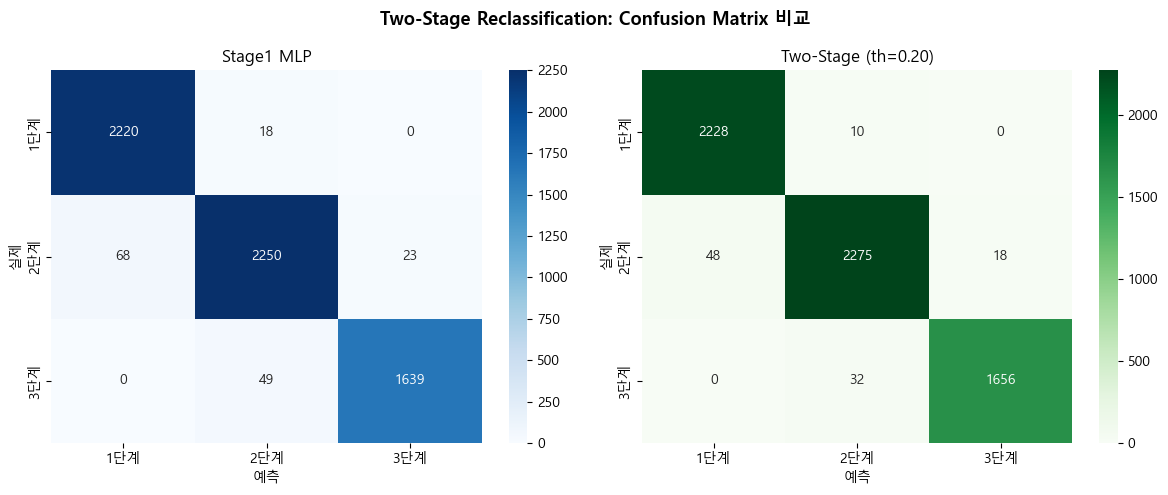


[저장 완료]
- C:\Users\user\Documents\GitHub\Team-3\models\MLP\MLP_two_stage_comparison.csv
- C:\Users\user\Documents\GitHub\Team-3\models\MLP\MLP_two_stage_val_threshold_tuning.csv
- C:\Users\user\Documents\GitHub\Team-3\models\MLP\MLP_two_stage_confusion_matrix.png


In [42]:
# 2단계 구조: 저확신 경계 샘플만 재분류 (0↔1, 1↔2 이진 보정기)
# 1차: MLP 확률 예측
# 2차: top2 margin이 작은 경계 샘플만 이진 분류기로 재판정

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

# -----------------------------
# 0) 공통 준비
# -----------------------------
feature_cols = [c for c in MODEL_FEATURES if c in train_df.columns]
if len(feature_cols) == 0:
    raise RuntimeError('MODEL_FEATURES가 데이터프레임 컬럼과 일치하지 않습니다.')

# 1차 MLP(베이스라인) 로드
stage1_model = MLP(input_dim=len(features), output_dim=3)
stage1_model.load_state_dict(torch.load(OUTPUT_DIR / 'best_mlp_model.pth'))
stage1_model.eval()


def get_probs_from_loader(model, loader):
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y_batch.cpu().numpy())
    return np.vstack(all_probs), np.concatenate(all_labels)


val_probs, val_true = get_probs_from_loader(stage1_model, val_loader)
test_probs, test_true = get_probs_from_loader(stage1_model, test_loader)

test_pred_stage1 = np.argmax(test_probs, axis=1)

# -----------------------------
# 1) 경계 전용 이진 보정기 학습 (train split 사용)
# -----------------------------
# 0 vs 1
train_01 = train_df[train_df['digital_stage'].isin([0, 1])].copy()
X01 = train_01[feature_cols].values
y01 = (train_01['digital_stage'].values == 1).astype(int)  # 1이면 class 1

clf_01 = LogisticRegression(max_iter=2000, class_weight='balanced')
clf_01.fit(X01, y01)

# 1 vs 2
train_12 = train_df[train_df['digital_stage'].isin([1, 2])].copy()
X12 = train_12[feature_cols].values
y12 = (train_12['digital_stage'].values == 2).astype(int)  # 1이면 class 2

clf_12 = LogisticRegression(max_iter=2000, class_weight='balanced')
clf_12.fit(X12, y12)

# -----------------------------
# 2) 저확신 경계 샘플 재분류 함수
# -----------------------------

def top2_info(prob_row):
    order = np.argsort(prob_row)[::-1]
    c1, c2 = int(order[0]), int(order[1])
    margin = float(prob_row[c1] - prob_row[c2])
    return c1, c2, margin


def apply_two_stage(df, probs, margin_threshold):
    # stage1 예측
    stage1_pred = np.argmax(probs, axis=1)
    final_pred = stage1_pred.copy()

    boundary_pairs = {(0, 1), (1, 2), (1, 0), (2, 1)}
    reclassified_count = 0

    X_all = df[feature_cols].values

    for i in range(len(probs)):
        c1, c2, margin = top2_info(probs[i])

        # top2가 경계 클래스 조합이고 margin이 작을 때만 재분류
        if (c1, c2) in boundary_pairs and margin < margin_threshold:
            x_row = X_all[i].reshape(1, -1)

            if set([c1, c2]) == {0, 1}:
                # clf_01 출력 1 -> class1, 0 -> class0
                pred_bin = clf_01.predict(x_row)[0]
                final_pred[i] = 1 if pred_bin == 1 else 0
                reclassified_count += 1

            elif set([c1, c2]) == {1, 2}:
                # clf_12 출력 1 -> class2, 0 -> class1
                pred_bin = clf_12.predict(x_row)[0]
                final_pred[i] = 2 if pred_bin == 1 else 1
                reclassified_count += 1

    return final_pred, reclassified_count


# -----------------------------
# 3) Validation으로 threshold 선택
# -----------------------------
threshold_grid = [0.03, 0.05, 0.07, 0.10, 0.12, 0.15, 0.20]
val_rows = []

for th in threshold_grid:
    val_pred_2stage, n_re = apply_two_stage(val_df.reset_index(drop=True), val_probs, th)

    acc = accuracy_score(val_true, val_pred_2stage)
    f1m = f1_score(val_true, val_pred_2stage, average='macro')
    rec2 = recall_score(val_true, val_pred_2stage, labels=[1], average='macro', zero_division=0)

    val_rows.append({
        'threshold': th,
        'val_accuracy': acc,
        'val_f1_macro': f1m,
        'val_recall_stage2': rec2,
        'reclassified_count': n_re,
    })

val_tune_df = pd.DataFrame(val_rows).sort_values('threshold').reset_index(drop=True)

# 선택 기준: val_accuracy 최대, 동률이면 val_f1_macro, 그다음 val_recall_stage2
best_row = val_tune_df.sort_values(
    ['val_accuracy', 'val_f1_macro', 'val_recall_stage2'],
    ascending=False
).iloc[0]
best_th = float(best_row['threshold'])

print('[Validation threshold tuning 결과]')
display(val_tune_df.round(4))
print(f"선택 threshold: {best_th:.2f}")

# -----------------------------
# 4) Test 적용 및 개선 전/후 비교
# -----------------------------
test_pred_2stage, test_reclassified = apply_two_stage(test_df.reset_index(drop=True), test_probs, best_th)

before_acc = accuracy_score(test_true, test_pred_stage1)
after_acc = accuracy_score(test_true, test_pred_2stage)

before_f1m = f1_score(test_true, test_pred_stage1, average='macro')
after_f1m = f1_score(test_true, test_pred_2stage, average='macro')

before_rec2 = recall_score(test_true, test_pred_stage1, labels=[1], average='macro', zero_division=0)
after_rec2 = recall_score(test_true, test_pred_2stage, labels=[1], average='macro', zero_division=0)

compare_df = pd.DataFrame([
    {'Model': 'Stage1 MLP', 'Accuracy': before_acc, 'F1_macro': before_f1m, 'Recall_2단계': before_rec2},
    {'Model': 'Two-Stage (Boundary Reclass)', 'Accuracy': after_acc, 'F1_macro': after_f1m, 'Recall_2단계': after_rec2},
])

compare_df.loc[1, 'Delta_Accuracy'] = after_acc - before_acc
compare_df.loc[1, 'Delta_F1_macro'] = after_f1m - before_f1m
compare_df.loc[1, 'Delta_Recall_2단계'] = after_rec2 - before_rec2

print('\n[Test 개선 전/후 비교]')
display(compare_df.round(4))
print(f"재분류된 샘플 수(test): {test_reclassified}")

# confusion matrix 생성 및 이미지 저장
cm_stage1 = confusion_matrix(test_true, test_pred_stage1)
cm_2stage = confusion_matrix(test_true, test_pred_2stage)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_stage1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['1단계', '2단계', '3단계'],
            yticklabels=['1단계', '2단계', '3단계'],
            ax=axes[0])
axes[0].set_title('Stage1 MLP')
axes[0].set_xlabel('예측')
axes[0].set_ylabel('실제')

sns.heatmap(cm_2stage, annot=True, fmt='d', cmap='Greens',
            xticklabels=['1단계', '2단계', '3단계'],
            yticklabels=['1단계', '2단계', '3단계'],
            ax=axes[1])
axes[1].set_title(f'Two-Stage (th={best_th:.2f})')
axes[1].set_xlabel('예측')
axes[1].set_ylabel('실제')

plt.suptitle('Two-Stage Reclassification: Confusion Matrix 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
cm_img_save = OUTPUT_DIR / 'MLP_two_stage_confusion_matrix.png'
plt.savefig(cm_img_save, dpi=300)
plt.show()

# 후속 셀에서 재사용 가능한 변수 저장
stage1_test_preds = test_pred_stage1.copy()
two_stage_test_preds = test_pred_2stage.copy()
two_stage_test_labels = test_true.copy()
two_stage_threshold = best_th

# 파일 저장 (CSV는 비교/튜닝표만 저장)
compare_save = OUTPUT_DIR / 'MLP_two_stage_comparison.csv'
val_tune_save = OUTPUT_DIR / 'MLP_two_stage_val_threshold_tuning.csv'

compare_df.to_csv(compare_save, index=False, encoding='utf-8-sig')
val_tune_df.to_csv(val_tune_save, index=False, encoding='utf-8-sig')

print('\n[저장 완료]')
print('-', compare_save)
print('-', val_tune_save)
print('-', cm_img_save)

## 개선 방법/결과 요약

### 1) 방법
| 단계 | 내용 |
|---|---|
| 1차 분류(기존) | MLP로 3클래스 확률 예측함. |
| 경계 샘플 선택 | top1-top2 margin이 작은 샘플만 선택함. |
| 2차 보정기 | 0↔1, 1↔2 이진 LogisticRegression으로 재분류함. |
| 적용 조건 | 경계쌍(0,1)/(1,2)이고 margin < threshold일 때만 보정함. |
| threshold 선택 | Validation에서 정확도 기준으로 탐색해 0.20 선택함. |

### 2) 결과
| 지표 | Stage1 MLP | Two-Stage | 변화 |
|---|---:|---:|---:|
| Accuracy | 0.9748 | 0.9828 | +0.0080 |
| F1 macro | 0.9752 | 0.9830 | +0.0078 |
| Recall(2단계) | 0.9611 | 0.9718 | +0.0107 |
| 재분류 샘플 수 | - | 178 | - |

### 3) Confusion Matrix 변화
| 항목 | 전 | 후 | 변화 |
|---|---:|---:|---:|
| 실제1→예측1 | 2220 | 2228 | +8 |
| 실제2→예측2 | 2250 | 2275 | +25 |
| 실제3→예측3 | 1639 | 1656 | +17 |
| 실제2→예측1 | 68 | 48 | -20 |
| 실제2→예측3 | 23 | 18 | -5 |
| 실제3→예측2 | 49 | 32 | -17 |
| 실제1→예측2 | 18 | 10 | -8 |

### 4) 해석
- 경계 샘플만 선택적으로 보정해서 불필요한 예측 변경을 줄였음.
- 2단계 Recall 개선과 전체 성능 개선을 동시에 달성함.
- 단일 MLP 대비 실사용성이 높아졌다고 판단함.